In [1]:
pip install opencv-python numpy matplotlib

Saving Parrots.bmp to Parrots (1).bmp


(np.float64(-0.5), np.float64(383.5), np.float64(255.5), np.float64(-0.5))

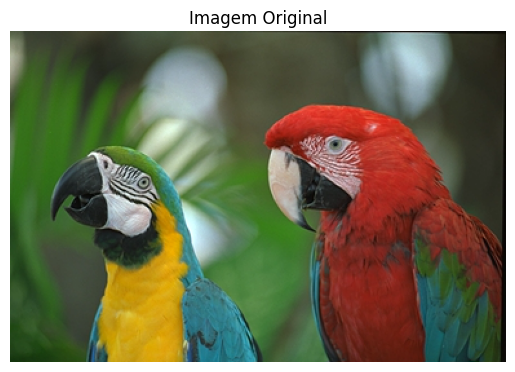

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

uploaded = files.upload()
img = cv2.imread("Parrots.bmp") # deve ser bitmap
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)
plt.title("Imagem Original")
plt.axis('off')

# ATIVIDADE 1

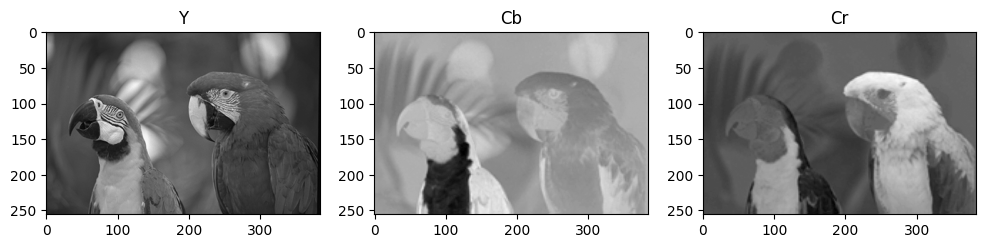

In [5]:
img_ycc = cv2.cvtColor(img, cv2.COLOR_RGB2YCrCb)
Y, Cr, Cb = cv2.split(img_ycc)
plt.figure(figsize=(12,5))
plt.subplot(1,3,1); plt.imshow(Y, cmap="gray"); plt.title("Y")
plt.subplot(1,3,2); plt.imshow(Cb, cmap="gray");
plt.title("Cb")
plt.subplot(1,3,3); plt.imshow(Cr, cmap="gray");
plt.title("Cr")
plt.show()

# ATIVIDADE 2

In [6]:
Cb_sub = cv2.resize(Cb, None, fx=0.5, fy=0.5,
interpolation=cv2.INTER_AREA)
Cr_sub = cv2.resize(Cr, None, fx=0.5, fy=0.5,
interpolation=cv2.INTER_AREA)

(np.float64(-0.5), np.float64(383.5), np.float64(255.5), np.float64(-0.5))

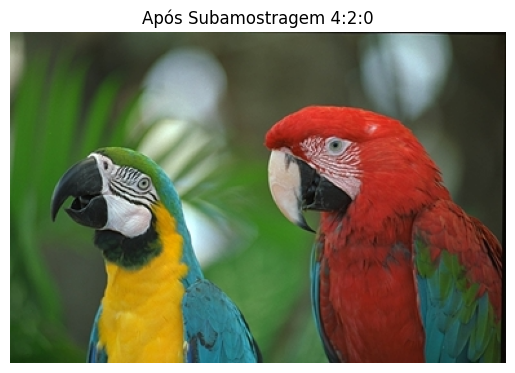

In [7]:
Cb_rec = cv2.resize(Cb_sub, (Cb.shape[1], Cb.shape[0]),
interpolation=cv2.INTER_LINEAR)
Cr_rec = cv2.resize(Cr_sub, (Cr.shape[1], Cr.shape[0]),
interpolation=cv2.INTER_LINEAR)
img_sub = cv2.merge([Y, Cr_rec, Cb_rec])
img_sub = cv2.cvtColor(img_sub, cv2.COLOR_YCrCb2RGB)
plt.imshow(img_sub)
plt.title("Após Subamostragem 4:2:0")
plt.axis("off")

# ATIVIDADE 3

In [11]:
def blocos8x8(channel):
 h, w = channel.shape
 blocks = []
 for i in range(0, h, 8):
  for j in range(0, w, 8):
    bloco = channel[i:i+8, j:j+8]
    if bloco.shape == (8,8):
      blocks.append(bloco)
  return blocks
Y_blocks = blocos8x8(Y)
len(Y_blocks)

48

# ATIVIDADE 4

In [12]:
def dct_2d(block):
 block = block.astype(np.float32) - 128
 return cv2.dct(block)
dct_blocks = [dct_2d(b) for b in Y_blocks]

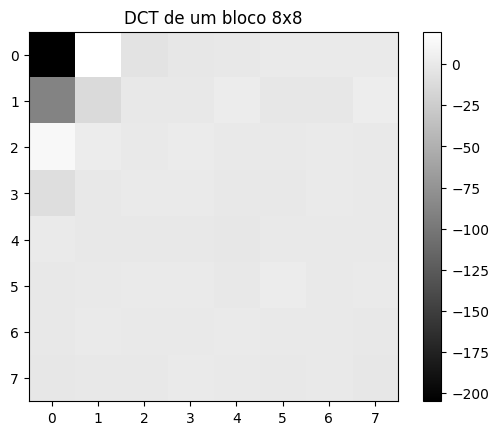

In [13]:
plt.imshow(dct_blocks[0], cmap='gray')
plt.title("DCT de um bloco 8x8")
plt.colorbar()

# ATIVIDADE 5

In [14]:
Q = np.array([
 [16,11,10,16,24,40,51,61],
 [12,12,14,19,26,58,60,55],
 [14,13,16,24,40,57,69,56],
 [14,17,22,29,51,87,80,62],
 [18,22,37,56,68,109,103,77],
 [24,35,55,64,81,104,113,92],
 [49,64,78,87,103,121,120,101],
 [72,92,95,98,112,100,103,99]
])
def quantize(block):
 return np.round(block / Q)
quant_blocks = [quantize(b) for b in dct_blocks]

ATIVIDADE 6

In [15]:
zigzag_idx = [
 (0,0),(0,1),(1,0),(2,0),(1,1),(0,2),(0,3),(1,2),
 (2,1),(3,0),(4,0),(3,1),(2,2),(1,3),(0,4),(0,5),
 (1,4),(2,3),(3,2),(4,1),(5,0),(6,0),(5,1),(4,2),
 (3,3),(2,4),(1,5),(0,6),(0,7),(1,6),(2,5),(3,4),
 (4,3),(5,2),(6,1),(7,0),(7,1),(6,2),(5,3),(4,4),
 (3,5),(2,6),(1,7),(2,7),(3,6),(4,5),(5,4),(6,3),
 (7,2),(7,3),(6,4),(5,5),(4,6),(3,7),(4,7),(5,6),
 (6,5),(7,4),(7,5),(6,6),(5,7),(6,7),(7,6),(7,7)
]
def zigzag(block):
 return np.array([block[i,j] for (i,j) in zigzag_idx])
zigzag_seq = zigzag(quant_blocks[0])
zigzag_seq

array([-13.,   2.,  -7.,   1.,  -1.,  -0.,  -0.,  -0.,   0.,  -1.,   0.,
        -0.,   0.,  -0.,  -0.,   0.,   0.,   0.,   0.,  -0.,  -0.,  -0.,
        -0.,  -0.,   0.,   0.,  -0.,   0.,   0.,  -0.,   0.,  -0.,  -0.,
         0.,   0.,  -0.,  -0.,   0.,   0.,  -0.,  -0.,   0.,   0.,   0.,
         0.,   0.,  -0.,   0.,  -0.,   0.,   0.,   0.,   0.,   0.,  -0.,
         0.,   0.,  -0.,  -0.,  -0.,   0.,  -0.,   0.,  -0.])

# ATIVIDADE 7

In [16]:
def dequantize(block):
 return block * Q
idct_blocks = [cv2.idct(dequantize(b.astype(np.float32))) + 128
for b in quant_blocks]

The full image reconstruction requires (image_height // 8) * (image_width // 8) = (256 // 8) * (384 // 8) = 32 * 48 = 1536 blocks.
Please check the 'blocos8x8' function in cell 'R-utCSbkaPwf' to ensure it returns all blocks.
Reconstructing only the available part of the image to avoid IndexError.


(np.float64(-0.5), np.float64(383.5), np.float64(255.5), np.float64(-0.5))

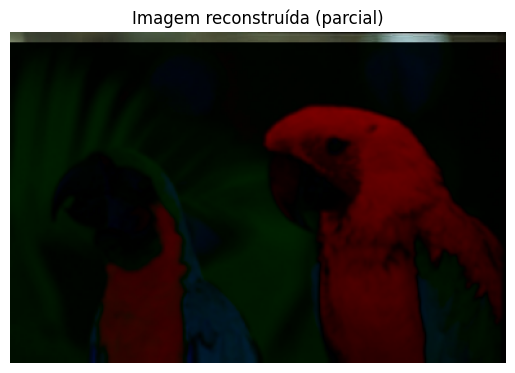

In [18]:
h, w = Y.shape
Y_rec = np.zeros((h, w))
k = 0
num_available_blocks = len(idct_blocks)

# Calculate how many full rows of 8x8 blocks are present in the available idct_blocks
# Assuming each row has w/8 blocks
blocks_per_row = w // 8
num_reconstructed_rows = 0
if blocks_per_row > 0:
    num_reconstructed_rows = num_available_blocks // blocks_per_row
    if num_available_blocks % blocks_per_row > 0: # If there are partial rows, count them
        num_reconstructed_rows += 1

print(f"Warning: Only {num_available_blocks} blocks are available from Y_blocks, corresponding to approximately {num_reconstructed_rows} rows of 8x8 blocks.")
print(f"The full image reconstruction requires (image_height // 8) * (image_width // 8) = ({h} // 8) * ({w} // 8) = {h // 8} * {w // 8} = {(h // 8) * (w // 8)} blocks.")
print("Please check the 'blocos8x8' function in cell 'R-utCSbkaPwf' to ensure it returns all blocks.")
print("Reconstructing only the available part of the image to avoid IndexError.")

for i in range(0, h, 8):
    for j in range(0, w, 8):
        if k < num_available_blocks:
            Y_rec[i:i+8, j:j+8] = idct_blocks[k]
            k += 1
        else:
            # If no more blocks are available, stop filling.
            break # Break from the inner loop
    if k >= num_available_blocks:
        break # Break from the outer loop as well

Y_rec = np.clip(Y_rec, 0, 255).astype(np.uint8)
img_rec = cv2.merge([Y_rec, Cr_rec, Cb_rec])
img_rec = cv2.cvtColor(img_rec, cv2.COLOR_YCrCb2RGB)
plt.imshow(img_rec)
plt.title("Imagem reconstruída (parcial)")
plt.axis("off")

# ATIVIDADE 8

In [19]:
def scale_quant_matrix(Q, quality):
 if quality < 50:
  scale = 5000 / quality
 else:
  scale = 200 - 2 * quality
 return np.clip((Q * scale / 100), 1, 255).astype(np.int32)

In [22]:
print(scale_quant_matrix(Q, 10))
print(scale_quant_matrix(Q, 30))
print(scale_quant_matrix(Q, 50))
print(scale_quant_matrix(Q, 70))
print(scale_quant_matrix(Q, 90))

[[ 80  55  50  80 120 200 255 255]
 [ 60  60  70  95 130 255 255 255]
 [ 70  65  80 120 200 255 255 255]
 [ 70  85 110 145 255 255 255 255]
 [ 90 110 185 255 255 255 255 255]
 [120 175 255 255 255 255 255 255]
 [245 255 255 255 255 255 255 255]
 [255 255 255 255 255 255 255 255]]
[[ 26  18  16  26  40  66  85 101]
 [ 20  20  23  31  43  96 100  91]
 [ 23  21  26  40  66  95 115  93]
 [ 23  28  36  48  85 145 133 103]
 [ 30  36  61  93 113 181 171 128]
 [ 40  58  91 106 135 173 188 153]
 [ 81 106 130 145 171 201 200 168]
 [120 153 158 163 186 166 171 165]]
[[ 16  11  10  16  24  40  51  61]
 [ 12  12  14  19  26  58  60  55]
 [ 14  13  16  24  40  57  69  56]
 [ 14  17  22  29  51  87  80  62]
 [ 18  22  37  56  68 109 103  77]
 [ 24  35  55  64  81 104 113  92]
 [ 49  64  78  87 103 121 120 101]
 [ 72  92  95  98 112 100 103  99]]
[[ 9  6  6  9 14 24 30 36]
 [ 7  7  8 11 15 34 36 33]
 [ 8  7  9 14 24 34 41 33]
 [ 8 10 13 17 30 52 48 37]
 [10 13 22 33 40 65 61 46]
 [14 21 33 38 48 62 67

# EXERCÍCIOS EXTRAS

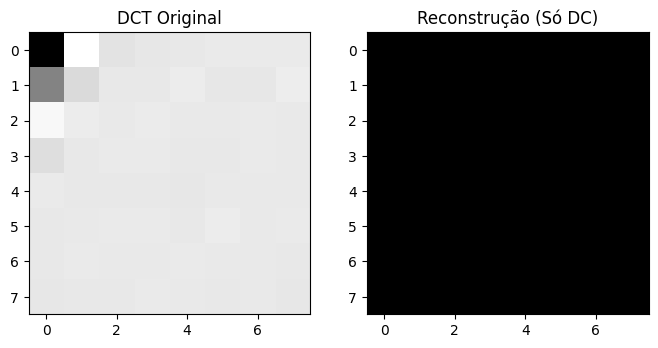

In [23]:
# Selecionando o primeiro bloco da lista gerada na Atividade 4
bloco_teste = dct_blocks[0].copy()

# Zerando todos os coeficientes AC (mantém apenas o DC na posição 0,0)
# Um bloco 8x8 tem 64 coeficientes; os AC são do índice 1 em diante
dc_only = np.zeros((8, 8))
dc_only[0, 0] = bloco_teste[0, 0]

# Reconstruindo apenas esse bloco
bloco_rec = cv2.idct(dc_only) + 128

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1); plt.imshow(bloco_teste, cmap='gray'); plt.title("DCT Original")
plt.subplot(1, 2, 2); plt.imshow(bloco_rec, cmap='gray'); plt.title("Reconstrução (Só DC)")
plt.show()

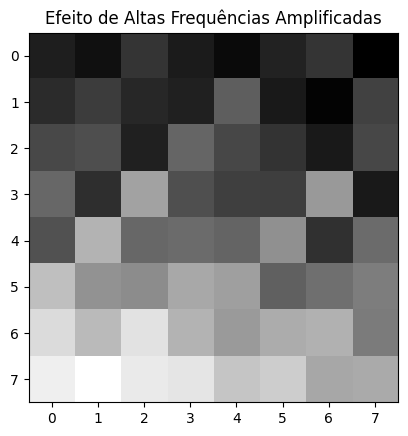

In [24]:
bloco_ruido = dct_blocks[0].copy()
# Multiplicando as altas frequências por um fator alto
bloco_ruido[4:, 4:] *= 10

img_ruido = cv2.idct(bloco_ruido) + 128
plt.imshow(img_ruido, cmap='gray')
plt.title("Efeito de Altas Frequências Amplificadas")
plt.show()

In [25]:
# 4:4:4 (Sem perda)
# Cb_444 = Cb.copy()

# 4:2:2 (Reduz apenas na largura)
Cb_422 = cv2.resize(Cb, None, fx=0.5, fy=1.0, interpolation=cv2.INTER_AREA)
Cb_res_422 = cv2.resize(Cb_422, (Cb.shape[1], Cb.shape[0]), interpolation=cv2.INTER_LINEAR)

# 4:2:0 (Reduz largura e altura - já feito na Atividade 2) [cite: 40, 41]

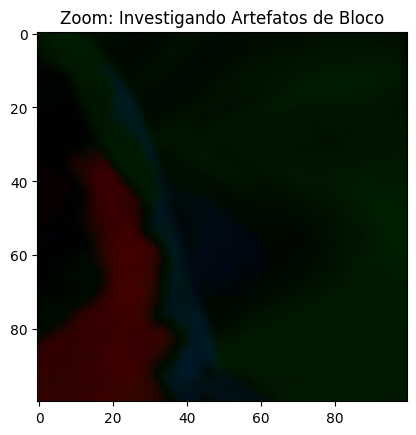

In [26]:
# Usando a imagem reconstruída da Atividade 7
plt.imshow(img_rec[100:200, 100:200]) # Zoom em uma área 100x100
plt.title("Zoom: Investigando Artefatos de Bloco")
plt.show()

In [27]:
def manual_zigzag(matrix):
    h, w = matrix.shape
    solution = [[] for _ in range(h + w - 1)]

    for i in range(h):
        for j in range(w):
            solution[i + j].append(matrix[i, j])

    result = []
    for i in range(len(solution)):
        if i % 2 == 0:
            result.extend(solution[i][::-1]) # Inverte para subir
        else:
            result.extend(solution[i]) # Mantém para descer
    return np.array(result)

# Teste com um bloco quantizado
print(manual_zigzag(quant_blocks[0]))

[-13.   2.  -7.   1.  -1.  -0.  -0.  -0.   0.  -1.   0.  -0.   0.  -0.
  -0.   0.   0.   0.   0.  -0.  -0.  -0.  -0.  -0.   0.   0.  -0.   0.
   0.  -0.   0.  -0.  -0.   0.   0.  -0.  -0.   0.   0.  -0.  -0.   0.
   0.   0.   0.   0.  -0.   0.  -0.   0.   0.   0.   0.   0.  -0.   0.
   0.  -0.  -0.  -0.   0.  -0.   0.  -0.]
